# Machine Trading — Chapter 2 Factor Models

이 노트북은 요인 위험·알파·예측 회귀를 연결하고 공식 예제의 실제 코드를
재현한다. 특히 책 수치를 만든 MATLAB 인덱싱 버그를 숨기지 않는다.

학습 질문은 다음과 같다.

1. 설명적 요인 모델과 다음 기간 예측 모델은 어떻게 다른가?
2. Fama–French 원본이 정말 시장중립 포트폴리오를 만드는가?
3. 27개 펀더멘털, ROE/BM, ROE 단일요인은 표본 외에서 책과 일치하는가?
4. PCA 요인의 경제적 의미와 재학습 비용은 무엇인가?
5. 옵션·short-interest·liquidity 데이터 부재를 어떻게 정직하게 표시하는가?

결과는 일부는 진짜 시간순 백테스트지만, 옵션 공식 예시는 백테스트가 아니다.

## 1. Chapter coverage / 재현 상태

| 주제 | 상태 | 근거 |
|---|---|---|
| 요인 위험·알파·예측 회귀 | 개념 설명 | 식 2.1/2.2 구분 |
| 예제 2.1 Fama–French | 근사 재현 | 원본 50숏/위에서 50번째 1롱과 수정 50/50 |
| 예제 2.2 27개 요인 | 수치 재현 | 63일 겹침 보유, 허용오차 1e-5 |
| 예제 2.3 ROE/BM·ROE | 수치 재현 | 21일 겹침 보유, 허용오차 1e-5 |
| 옵션 내재 모멘트 5종 | 수식 예시·백테스트 불가 | licensed option panel 부재 |
| 공매도 잔고·유동성 | 개념 설명·데이터 부재 | 보고 지연/주식수 입력 필요 |
| 예제 2.5 PCA | 저빈도 방법 적응 | 252일 창, 21일 재학습 |
| 결합·다중정렬 | 개념 설명 | 공선성·train-only 선택 |
| 연습문제 | 범위 밖 | 장 원문에 보존 |

**재현 분류:** exact numerical reproduction, approximate comparison,
methodological adaptation, unavailable licensed data를 구분한다.

## 2. 핵심 수식과 formula-to-code

시계열 예측:

$$R_{t+1,s}-r_F=\alpha_s+\beta_s^T f_t+\epsilon_{t+1,s}$$

횡단면 예측:

$$R_{t+h,s}=\alpha+\gamma^T x_{t,s}+\epsilon_{t+h,s}$$

| 수식 | 구현 함수 |
|---|---|
| $P_t/P_{t-h}-1$ | `net_returns` |
| 종목별 시계열 OLS | `fit_fama_french` |
| pooled 횡단면 OLS | `fit_cross_sectional_model` |
| 겹침 보유 | `overlapping_positions` |
| 과거 252일 PCA | `fit_pca_adaptation` |
| 비용 차감 | `daily_returns_from_positions` |

random_seed = None이다. 난수는 없고 같은 BLAS 환경의 결정론적 선형대수만 쓴다.

In [1]:
from io import BytesIO
from pathlib import Path
import sys
from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("project root not found")

PROJECT_ROOT = find_project_root()
SRC = PROJECT_ROOT / "chapter_2_factor_models/src"
sys.path.insert(0, str(SRC))
from run_chapter2_analysis import (
    AUDIT_SCRIPT_PATH, BOOK_RESULTS, CHAPTER_COVERAGE, FAMA_FRENCH_PATH,
    FUNDAMENTAL_DATA_PATH, FUNDAMENTALS_PATH, PYPROJECT_PATH, UV_LOCK_PATH,
    VERIFICATION_CLASSES,
    chapter_manifest, create_diagnostics_figure, create_equity_figure,
    create_factor_map_figure, environment_versions, implied_moment_example,
    load_chapter_data, run_experiments, sha256_file, validate_offline_assets,
    verify_results, verification_summary,
)

validate_offline_assets()

def show_figure(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=140, bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buffer.getvalue()))

print("official chapter archive members: checksum verified")

official chapter archive members: checksum verified


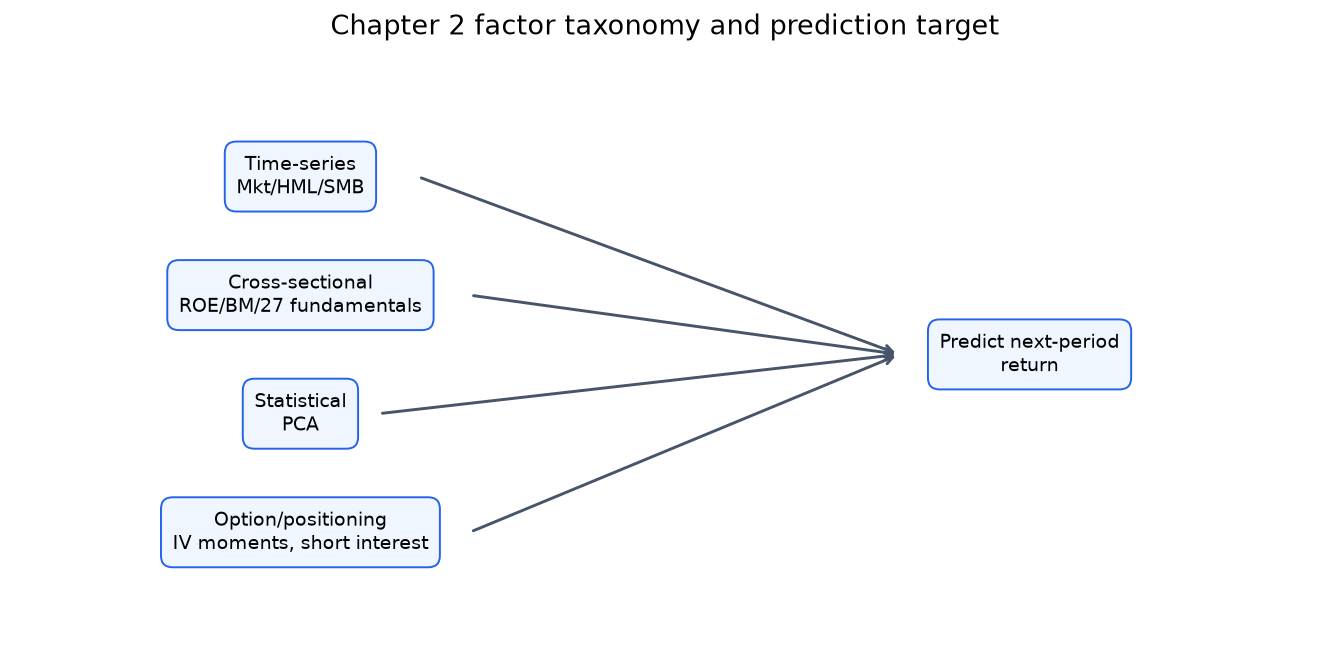

In [2]:
show_figure(create_factor_map_figure())

## 3. Provenance와 잠금 환경

공식 페이지·직접 ZIP·아카이브 SHA-256·개별 추출 파일 SHA-256·`uv.lock`
SHA-256을 함께 둔다. 원시 데이터가 바뀌면 offline 검증이 즉시 실패한다.

In [3]:
manifest = chapter_manifest()
provenance = pd.Series({
    "source_page": manifest["source_page"],
    "archive_url": manifest["url"],
    "archive_sha256": manifest["sha256"],
    "fundamentalData_sha256": sha256_file(FUNDAMENTAL_DATA_PATH),
    "fundamentals_sha256": sha256_file(FUNDAMENTALS_PATH),
    "fama_french_sha256": sha256_file(FAMA_FRENCH_PATH),
    "uv_lock_sha256": sha256_file(UV_LOCK_PATH),
})
display(provenance.to_frame("value"))
display(pd.Series(environment_versions()).to_frame("version"))

,value
source_page,https://epchan.com/book3
archive_url,https://epchan.com/img/book3/Chap2%20Factor%20...
archive_sha256,9a8f4c1620a80c1f6f031703ef5e0bc3f75cccf6cda1a8...
fundamentalData_sha256,72e1e59bbab7a75e263684aa053794a523a161e5f8d2f6...
fundamentals_sha256,211bb40db1253d656b356e79203920f7c0b17a4102ab52...
fama_french_sha256,864738f814d3268ab41cb208b4fc974edf37626b632279...
uv_lock_sha256,d3b494323b4b7b207e1f32e4f86e1c42e24d90afc8b86e...


,version
python,3.12.3
numpy,2.5.1
pandas,3.0.3
scipy,1.18.0
matplotlib,3.11.1
nbformat,5.10.4
nbclient,0.11.0


## 4. 데이터 구조와 결측 진단

가격은 2007–2013년 743개 역사적 SPX 종목의 mid quote다. 결측을 0으로
바꾸지 않는다. 회귀 적합은 유한한 행만 쓰고, 포트폴리오 P&L은 해당 날짜에
가격 수익률이 없는 종목을 합산에서 제외한다. 이는 원본 `smartsum` 의미를
따르지만 denominator에는 선택 포지션이 남는다는 점도 기억해야 한다.

In [4]:
data = load_chapter_data()
diagnostics = pd.Series({
    "start": data.dates[0].date(), "end": data.dates[-1].date(),
    "rows": len(data.dates), "stocks": len(data.symbols),
    "missing_prices": int(np.count_nonzero(~np.isfinite(data.mid))),
    "nonpositive_finite": int(np.count_nonzero(np.isfinite(data.mid) & (data.mid <= 0))),
    "cross_sectional_factors": len(data.factor_names),
})
display(diagnostics.to_frame("value"))
display(pd.Series(np.mean(~np.isfinite(data.mid), axis=0)).describe().to_frame("missing fraction"))

,value
start,2007-01-03
end,2013-12-31
rows,1762
stocks,743
missing_prices,430075
nonpositive_finite,0
cross_sectional_factors,27


,missing fraction
count,743.000000
mean,0.328511
std,0.387359
min,0.000000
25%,0.000000
50%,0.086833
75%,0.715948
max,1.000000


## 5. 모든 실행 실험

다음 셀은 예제 2.1의 원본/수정본, 예제 2.2의 27요인, 예제 2.3의 두 모델,
예제 2.5의 저빈도 PCA 적응을 실제로 계산한다. 전반부 학습·후반부 테스트를
고정하며 비용 민감도는 편도 2bps다.

,train_cagr,train_sharpe,test_cagr,test_sharpe,test_cagr_2bps,max_drawdown
experiment,,,,,,
fama_official,1.049994,2.470537,-0.065504,-0.597906,-0.121774,-0.231818
fama_corrected,1.094494,5.815996,0.038030,1.185178,-0.027778,-0.026671
cross27,0.043255,0.391330,0.123549,1.675774,0.121656,-0.076124
roe_bm,0.050343,0.370628,0.093199,1.010660,0.086001,-0.120718
roe_only,0.014004,0.177303,0.201661,1.305036,0.193749,-0.182143
pca,0.000000,NaN,-0.008212,-0.023841,-0.011683,-0.211943


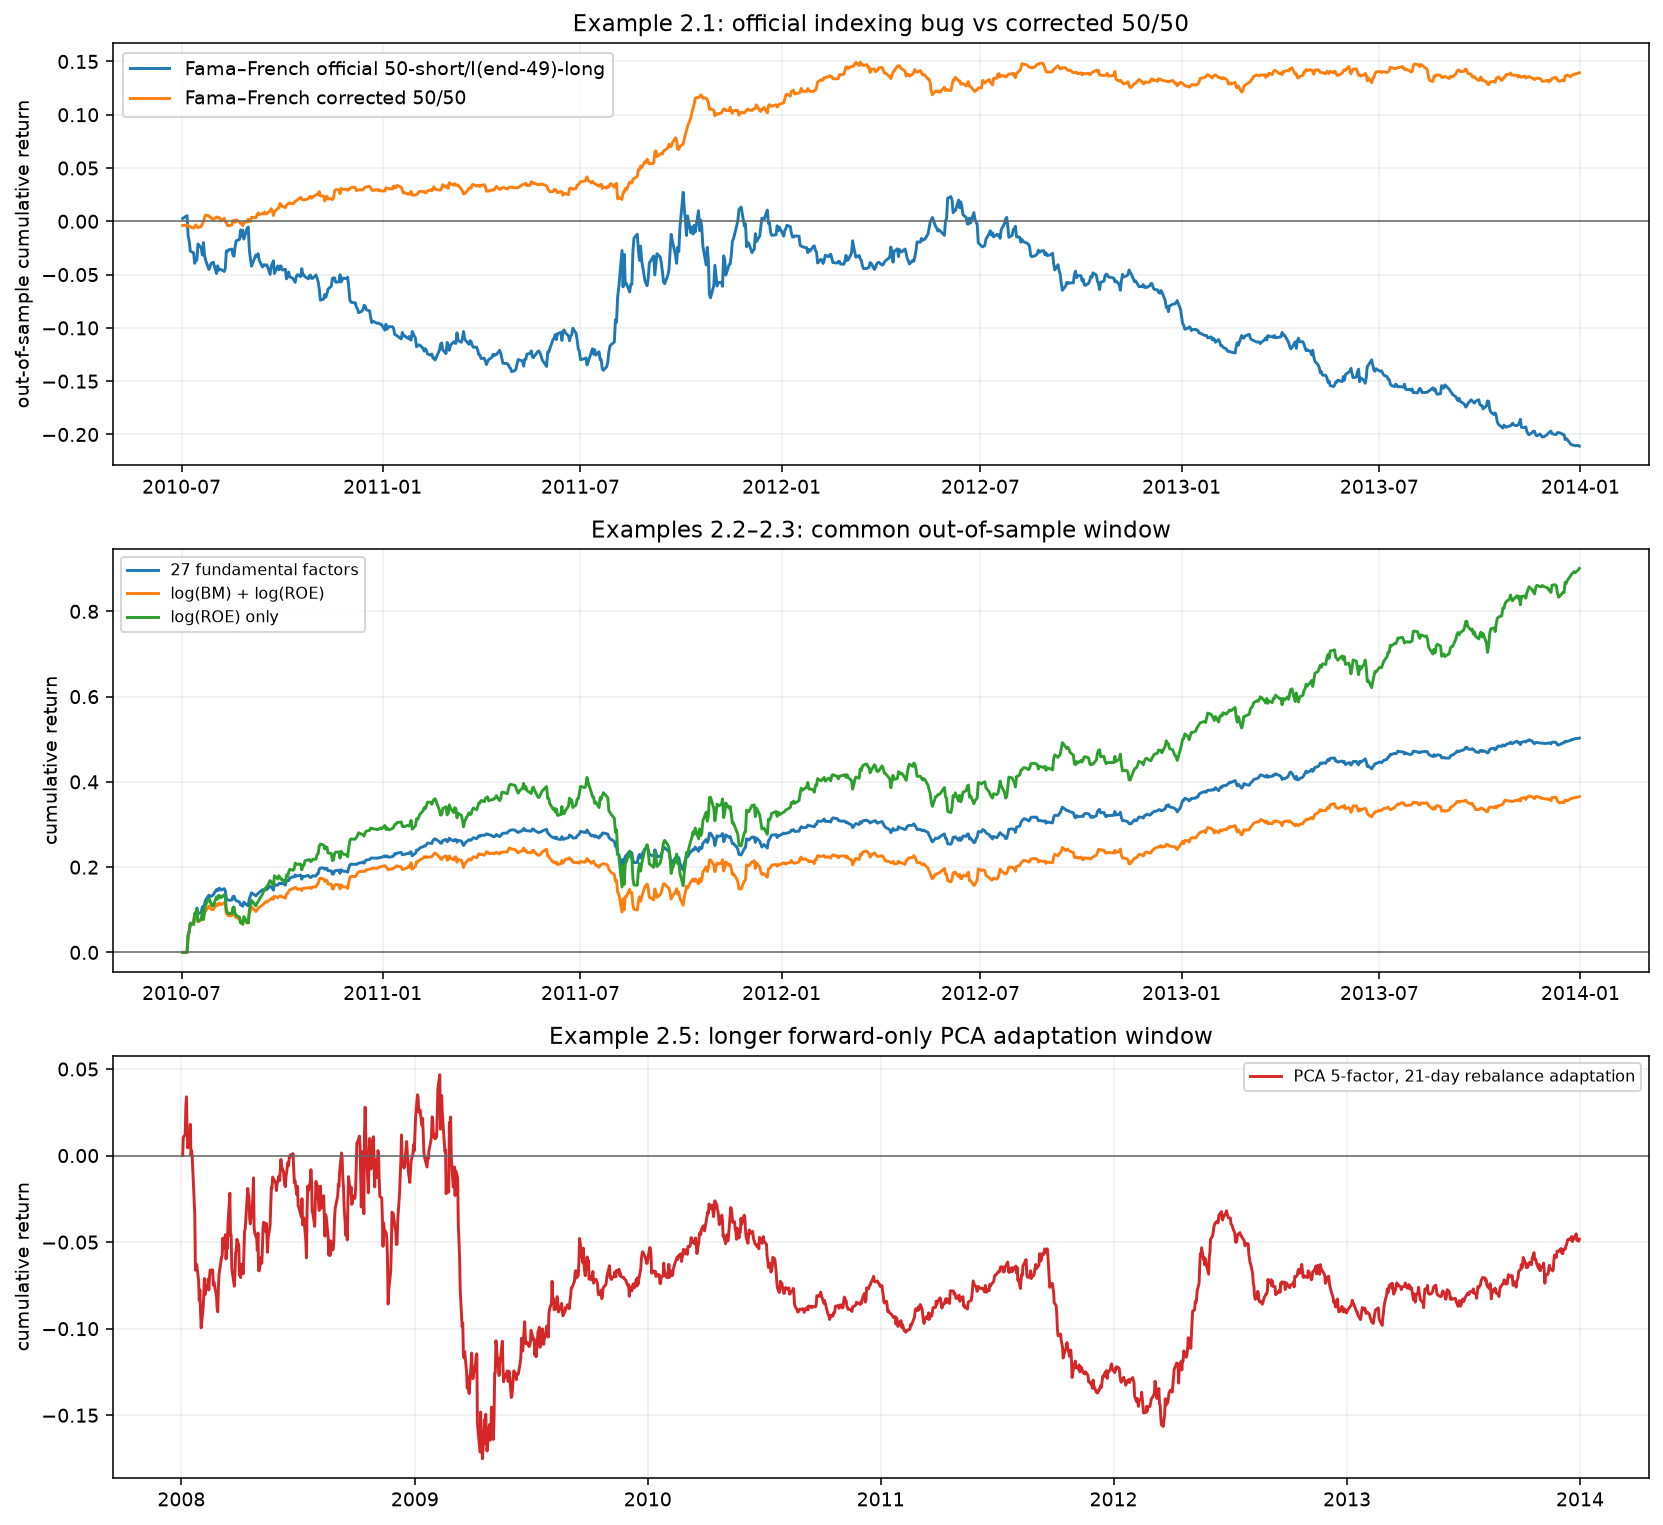

In [5]:
results = run_experiments(data)
rows=[]
for key, result in results.items():
    rows.append({
        "experiment": key, "train_cagr": result.train.cagr,
        "train_sharpe": result.train.sharpe, "test_cagr": result.test.cagr,
        "test_sharpe": result.test.sharpe,
        "test_cagr_2bps": result.test_with_cost.cagr,
        "max_drawdown": result.test.maximum_drawdown,
    })
result_table=pd.DataFrame(rows).set_index("experiment")
display(result_table)
show_figure(create_equity_figure(results))

## 6. Example 2.1 — 버그 재현과 수정

원본 숏 선택은 50개지만 롱 선택은 `I(end-topN+1)`, 즉 위에서 50번째 하나뿐이다.
책 값과의 비교는 CAGR 0.03/0.02, Sharpe 0.08 허용오차의 **근사 재현**이다.
수정 50/50은 각 날짜 종목 수 기준 dollar neutral이지만 beta·산업 중립은 아니다.
원본 수치와 수정 전략을 같은 열에서 비교해 “Python이 개선했다”고 과장하지 않는다.

In [6]:
book_rows=[]
mapping={"fama_official":"fama_french_official","cross27":"cross_sectional_27","roe_bm":"roe_bm","roe_only":"roe_only"}
for key, book_key in mapping.items():
    r=results[key]; b=BOOK_RESULTS[book_key]
    grade="근사 재현" if key=="fama_official" else "수치 재현"
    book_rows.append({"experiment":key,"grade":grade,"python_cagr":r.test.cagr,"book_cagr":b["test_cagr"],"python_sharpe":r.test.sharpe,"book_sharpe":b["test_sharpe"]})
display(pd.DataFrame(book_rows).set_index("experiment"))
official=results["fama_official"].positions
corrected=results["fama_corrected"].positions
assert results["fama_official"].metadata["long_rank_from_top"] == 50
assert abs(results["fama_official"].train.sharpe-BOOK_RESULTS["fama_french_official"]["train_sharpe"]) <= 0.08
display(pd.Series({"official_long_rank_from_top":50,"official_min_net_count":np.min(official.sum(axis=1)),"corrected_max_abs_net_count":np.max(np.abs(corrected.sum(axis=1)))},name="position diagnostic").to_frame())

,grade,python_cagr,book_cagr,python_sharpe,book_sharpe
experiment,,,,,
fama_official,근사 재현,-0.065504,-0.070378,-0.597906,-0.643982
cross27,수치 재현,0.123549,0.123549,1.675774,1.675774
roe_bm,수치 재현,0.093199,0.093199,1.010660,1.010660
roe_only,수치 재현,0.201661,0.201661,1.305036,1.305036


,position diagnostic
official_long_rank_from_top,50.0
official_min_net_count,-49.0
corrected_max_abs_net_count,0.0


## 7. Examples 2.2–2.3 — 왜 ROE 단일요인이 더 강했나

27요인은 많은 변수를 한꺼번에 쓰므로 공선성과 high-leverage point에 민감하다.
ROE/BM 모델도 두 계수의 부호가 경제 직관과 항상 같지 않다. 책과 동일하게
ROE 단일요인의 OOS CAGR이 약 20%로 더 높지만, 이는 한 역사적 표본의 결과다.
회계 발표시각과 수정 이력을 point-in-time으로 검증하지 못했으므로 실전 알파
증거가 아니라 코드·수치 재현으로 한정한다.

In [7]:
exact_checks={
    "cross27_cagr": abs(results["cross27"].test.cagr-BOOK_RESULTS["cross_sectional_27"]["test_cagr"]) <= 1e-5,
    "cross27_sharpe": abs(results["cross27"].test.sharpe-BOOK_RESULTS["cross_sectional_27"]["test_sharpe"]) <= 1e-5,
    "roe_bm_cagr": abs(results["roe_bm"].test.cagr-BOOK_RESULTS["roe_bm"]["test_cagr"]) <= 1e-5,
    "roe_only_cagr": abs(results["roe_only"].test.cagr-BOOK_RESULTS["roe_only"]["test_cagr"]) <= 1e-5,
}
display(pd.Series(exact_checks, name="수치 재현 assertion").to_frame())
assert all(exact_checks.values())

,수치 재현 assertion
cross27_cagr,True
cross27_sharpe,True
roe_bm_cagr,True
roe_only_cagr,True


## 8. Example 2.5 — PCA 통계적 요인

PCA는 공분산의 서로 직교하는 방향을 찾지만 부호·순서·경제 의미가 창마다
바뀔 수 있다. 책은 매일 재학습하지만 여기서는 21일마다 재학습한다. 따라서
책의 CAGR 15.6%와 직접 수치 비교하지 않는 methodological adaptation이다.
과거 252일 바깥의 미래 수익률은 학습 행렬에 들어가지 않는다.

,value
lookback,252
components,5
rebalance_every,21
rebalances,72
mean_explained_variance,0.542943
reproduction_classification,lower-frequency methodological adaptation


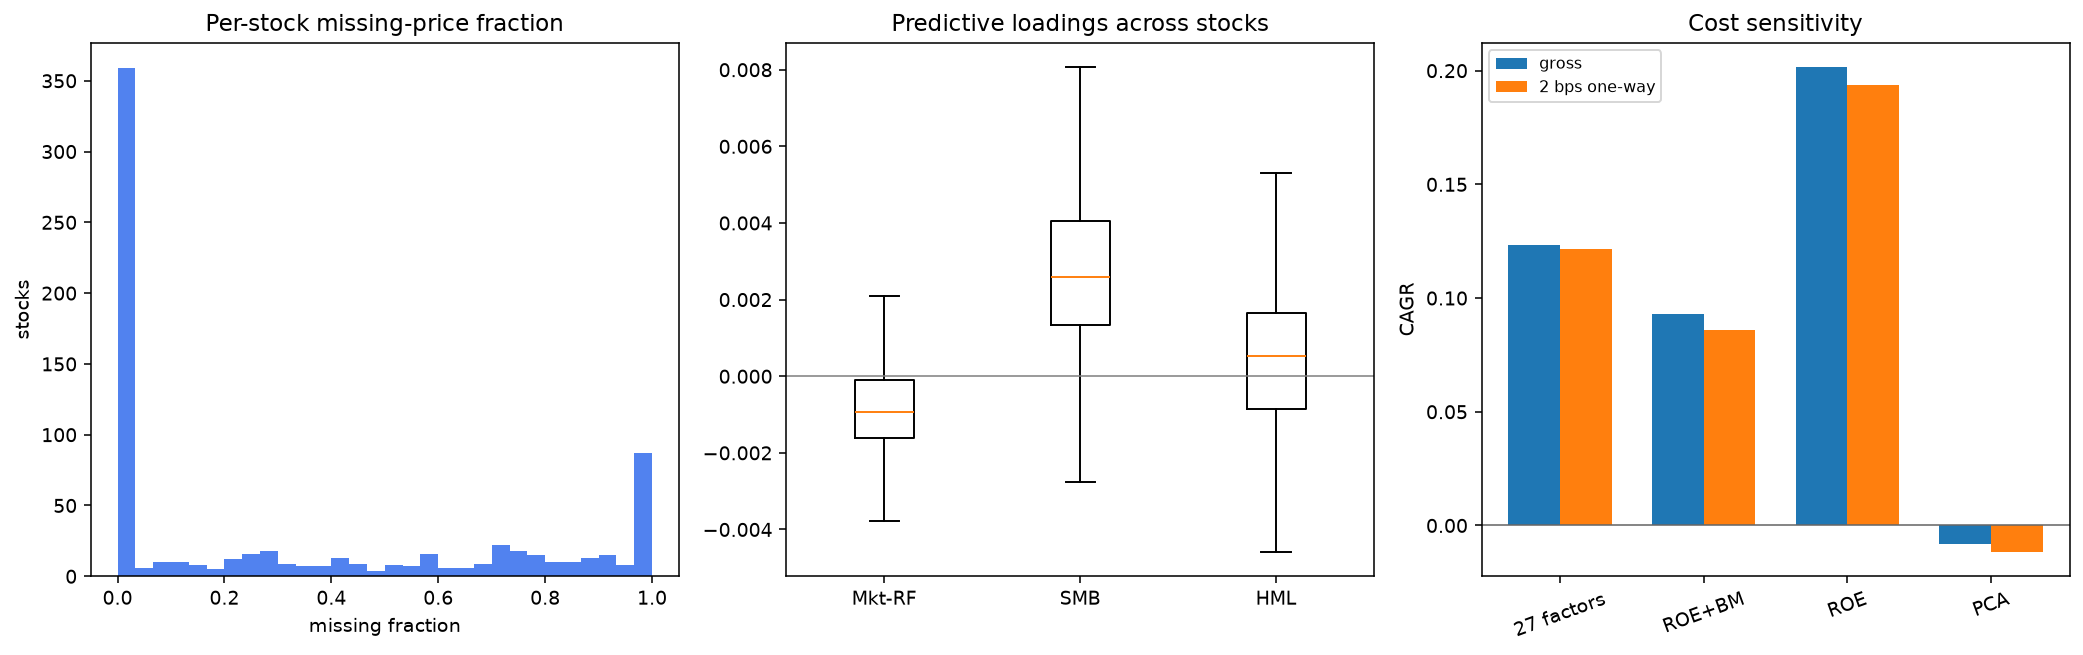

In [8]:
pca=results["pca"]
assert pca.metadata["reproduction_classification"] == "lower-frequency methodological adaptation"
assert not np.any(pca.positions[:pca.metadata["lookback"]])
display(pd.Series(pca.metadata).to_frame("value"))
show_figure(create_diagnostics_figure(data, results))

## 9. 옵션 내재 모멘트 — 수식 점검만

ATM call/put IV를 $C_A,P_A$, OTM을 $C_O,P_O$라 두면 예시 proxy는

$$IV=(C_A+P_A)/2,\quad Skew=C_O-P_O,$$
$$Kurt=(C_O+P_O)-(C_A+P_A).$$

30일 만기·목표 델타로 보간한 실제 option panel이 ZIP에 없으므로 이 셀은
산술 identity만 검증한다. 이는 옵션 수익률 백테스트가 아니다.

In [9]:
option_example=implied_moment_example()
assert np.isclose(option_example["implied_volatility"], 0.23)
assert np.isclose(option_example["implied_skewness_proxy"], -0.12)
display(pd.Series(option_example).to_frame("value"))

,value
implied_volatility,0.23
implied_skewness_proxy,-0.12
implied_kurtosis_proxy,0.04
atm_call,0.22
atm_put,0.24
otm_call,0.19
otm_put,0.31


## 10. 공매도 잔고·유동성·요인 결합

short interest는 공표 지연과 대차 가능성, liquidity는 거래량 조정과 당시
shares outstanding이 필요하다. 원본 `liquidity.m`도 외부 Compustat 경로를
요구한다. 데이터 부재를 현대 대체 데이터로 조용히 덮지 않는다.

여러 요인을 결합할 때는 AIC/BIC나 rank/multisort를 **학습셋 안에서만** 선택해야
한다. 산업·시가총액별 요인 부호가 달라질 수 있고, 단순 50/50은 각 요인 노출을
0으로 만들지 않는다.

## 11. Bias, 비용, OOS 한계

- look-ahead: 회계값의 실제 공개일을 검증하지 못했다.
- survivorship/selection bias: 책의 CRSP 설명에 의존한다.
- transaction cost: 편도 2bps 외 borrow fee·locate·impact·slippage가 없다.
- data snooping: 요인·보유기간·topN·정렬순서 최적화가 성과를 부풀릴 수 있다.
- OOS: 시간분할은 했지만 단 하나의 holdout이고 walk-forward 반복 검증이 아니다.
- risk metrics: CAGR·Sharpe·maximum drawdown은 tail liquidity를 완전히 설명하지 않는다.

## 12. 자동 검증

책 수치·아카이브 hash 대조와 포지션/수식 invariant를 분리한다. invariant를
외부 재현 증거로 세지 않는다.

In [10]:
checks=verify_results(results, option_example)
summary=verification_summary(checks)
verification=pd.DataFrame({"passed":checks,"class":{k:VERIFICATION_CLASSES[k] for k in checks}})
display(verification)
display(pd.Series(summary).drop("classification").to_frame("count"))
assert verification["passed"].all()
print(f"{summary['total']} checks passed")

,passed,class
archive_manifest_matches,True,independent_or_empirical
fama_train_cagr_matches_book,True,independent_or_empirical
fama_train_sharpe_matches_book,True,independent_or_empirical
fama_test_cagr_matches_book,True,independent_or_empirical
fama_test_sharpe_matches_book,True,independent_or_empirical
cross27_test_metrics_match_book,True,independent_or_empirical
roe_bm_test_metrics_match_book,True,independent_or_empirical
roe_only_test_metrics_match_book,True,independent_or_empirical
corrected_fama_is_dollar_neutral,True,contract_invariant
official_fama_exposes_indexing_bug,True,contract_invariant


,count
total,15
passed,15
independent_or_empirical,8
contract_invariant,7


15 checks passed


## 13. 결론

예측 요인의 성능은 수식만이 아니라 정보 시점, 종목 선택, 포지션 대칭성,
보유기간, 비용에 달려 있다. 예제 2.1의 콜론 하나가 시장중립을 순숏으로 바꾼
사실이 가장 강한 교훈이다. 예제 2.2·2.3의 책 수치는 재현했지만 미래에도 같은
알파가 있다는 뜻은 아니다. PCA는 데이터만으로 요인을 만들 수 있으나 경제적
안정성과 비용을 별도 검증해야 한다.

따라서 이 장의 재사용 가능한 절차는 source/checksum → 가용시점 → train/OOS →
포지션 계약 → 비용 → 책 비교 → 편향 경고의 순서다. 각 단계의 실패는 다음
단계의 높은 Sharpe보다 먼저 설명하고 수정해야 한다.